In [ ]:
# STEP 1: LOAD DATASET
import pandas as pd
import numpy as np
import datetime

# Load CarDekho dataset directly
data_url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/car%20data.csv"
df = pd.read_csv(data_url)

# Clean duplicates and basic missing values
df = df.drop_duplicates()

# Feature Engineering: Age & Brand
current_year = datetime.datetime.now().year
df['Car_Age'] = current_year - df['Year']
df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split()[0])

print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
df.head()

Data loaded successfully!
Dataset shape: (299, 11)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift


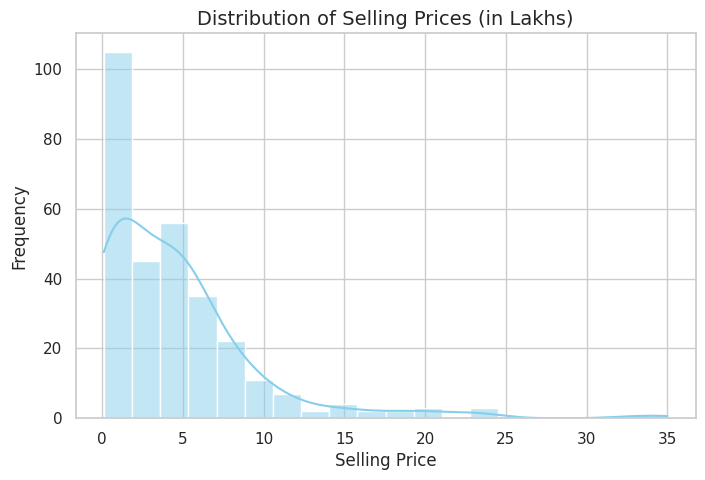

In [ ]:
# STEP 2: GRAPH 1 - SELLING PRICE DISTRIBUTION
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.histplot(df['Selling_Price'], kde=True, color='skyblue', bins=20)
plt.title("Distribution of Selling Prices (in Lakhs)", fontsize=14)
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_713/2426373751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')


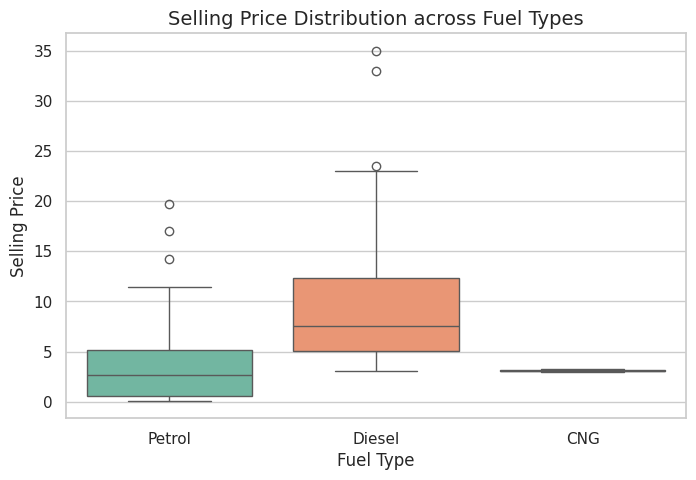

In [ ]:
# STEP 3: GRAPH 2 - PRICE VS FUEL TYPE
plt.figure(figsize=(8, 5))

sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
plt.title("Selling Price Distribution across Fuel Types", fontsize=14)
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

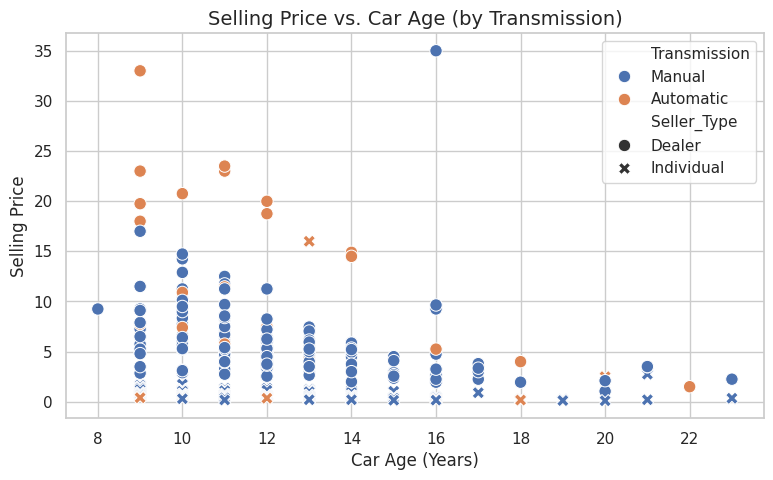

In [ ]:
# STEP 4: GRAPH 3 - PRICE VS CAR AGE
plt.figure(figsize=(9, 5))

sns.scatterplot(x='Car_Age', y='Selling_Price', hue='Transmission', style='Seller_Type', data=df, s=80)
plt.title("Selling Price vs. Car Age (by Transmission)", fontsize=14)
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()

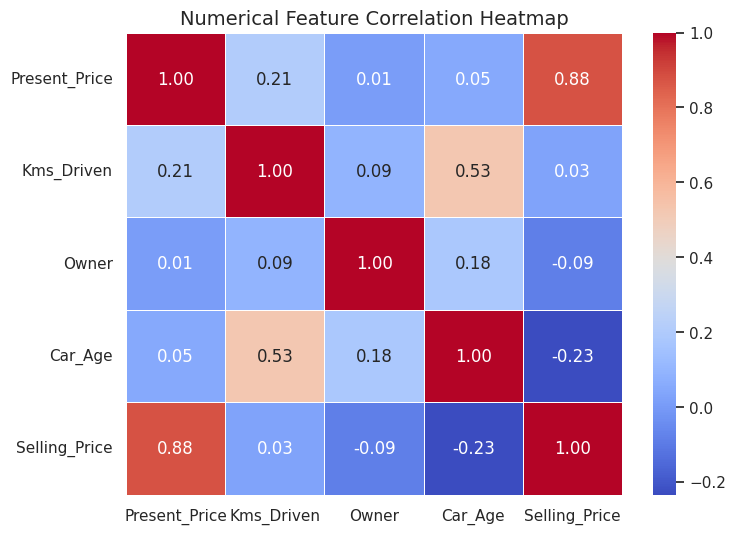

In [ ]:
# STEP 5: GRAPH 4 - FEATURE CORRELATION HEATMAP
numerical_cols = ['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Selling_Price']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Numerical Feature Correlation Heatmap", fontsize=14)
plt.show()

In [ ]:
# STEP 6: MODEL TRAINING & EVALUATION METRICS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
X = df.drop(columns=['Selling_Price', 'Year', 'Car_Name'])
y = df['Selling_Price']

categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']
num_cols = ['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2})
    trained_pipelines[name] = pipe

# Display evaluation table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model      MAE     RMSE  R2 Score
Linear Regression 1.474063 2.795791  0.696723
    Random Forest 1.388733 3.388078  0.554613
Gradient Boosting 1.103790 2.546838  0.748329


/tmp/ipykernel_713/2164974021.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='magma')


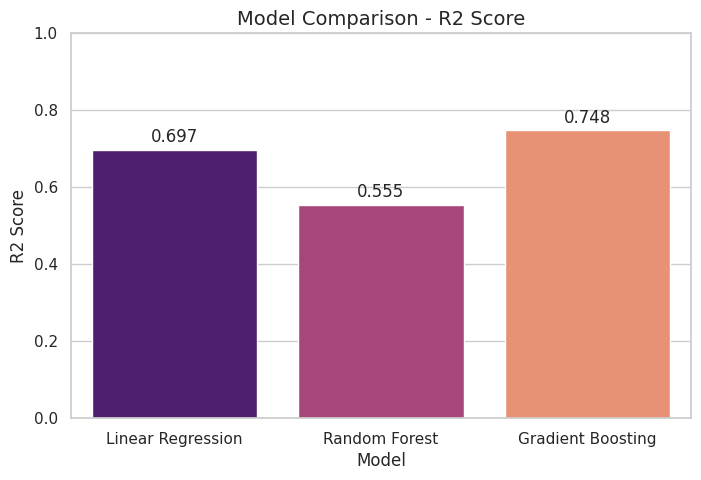

In [ ]:
# STEP 7: MODEL COMPARISON GRAPH
plt.figure(figsize=(8, 5))

sns.barplot(x='Model', y='R2 Score', data=results_df, palette='magma')
plt.title("Model Comparison - R2 Score", fontsize=14)
plt.ylim(0, 1.0)
for index, row in results_df.iterrows():
    plt.text(index, row['R2 Score'] + 0.02, f"{row['R2 Score']:.3f}", ha='center')

plt.show()

/tmp/ipykernel_713/568547084.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


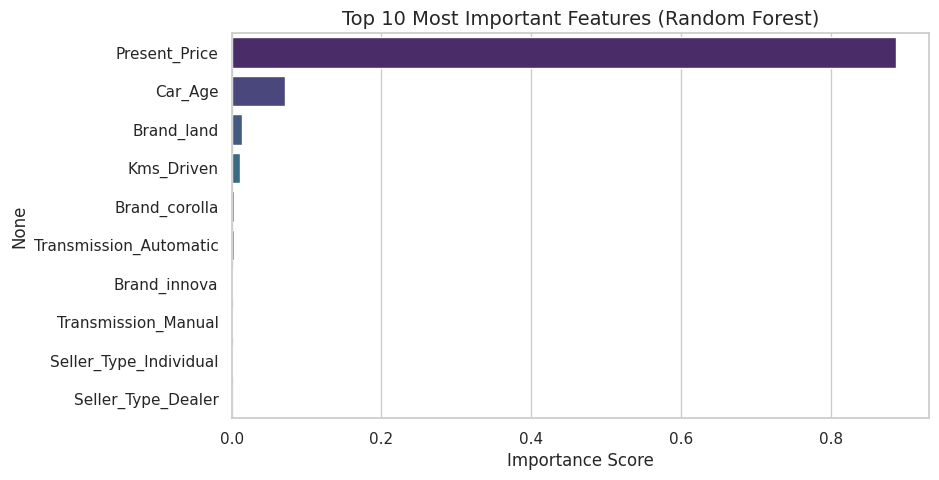

In [ ]:
# STEP 8: FEATURE IMPORTANCE CHART
best_pipe = trained_pipelines["Random Forest"]
rf_model = best_pipe.named_steps['model']

# Extract feature names after One-Hot Encoding
encoded_cat_cols = list(
    best_pipe.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_cols)
)
all_features = num_cols + encoded_cat_cols

# Get importances
importances = rf_model.feature_importances_
top_features = pd.Series(importances, index=all_features).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title("Top 10 Most Important Features (Random Forest)", fontsize=14)
plt.xlabel("Importance Score")
plt.show()

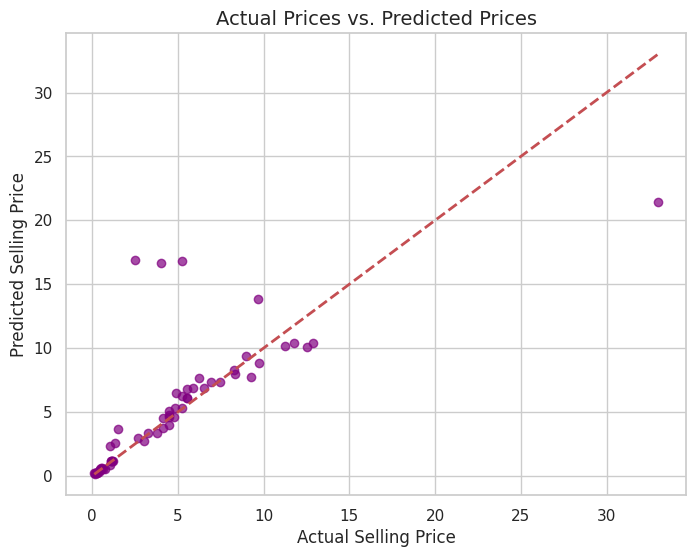

In [ ]:
# STEP 9: ACTUAL VS PREDICTED PRICE CHART
best_preds = best_pipe.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual Prices vs. Predicted Prices", fontsize=14)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.show()